In [24]:
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
t1 = pd.read_excel("RunningTimeRecord.xlsx", sheet_name="Testing 1", skiprows=3)

t1.head()

,n,Computational Time (sec),Overall Time (sec),Computational Time (sec).1,Overall Time (sec).1,Speedup,Computational Time (sec).2,Overall Time (sec).2
0,10000000,4.162395,9.410032,0.687085,4.681508,6.05805,1.446939,6.791579
1,15000000,7.627834,15.93717,1.166452,7.507098,6.539347,2.235206,9.926008
2,20000000,11.705761,22.592574,1.764826,10.757872,6.632813,2.933256,13.217007
3,25000000,15.923991,28.822953,2.375774,13.035808,6.702654,3.563179,16.510265
4,30000000,20.415963,35.881966,3.023092,15.552024,6.753338,4.292649,19.987759


In [26]:
t1_8 = t1.iloc[0:9, [0,5]].copy()

t1_8

,n,Speedup
0,10000000,6.05805
1,15000000,6.539347
2,20000000,6.632813
3,25000000,6.702654
4,30000000,6.753338
5,35000000,6.736967
6,40000000,7.011047
7,45000000,7.030983
8,50000000,7.472347


In [27]:
t1_32 = t1.iloc[13:22, [0,5]].copy()

t1_32

,n,Speedup
13,10000000,20.032841
14,15000000,20.705039
15,20000000,22.604393
16,25000000,21.698589
17,30000000,22.768992
18,35000000,20.10442
19,40000000,23.750456
20,45000000,23.521188
21,50000000,21.820899


In [28]:
df1 = pd.merge(t1_8, t1_32, on='n')

df1.rename(
    columns={
        "Speedup_x": "speedup_8cores",
        "Speedup_y": "speedup_32cores"
    },
    inplace=True
)

df1

,n,speedup_8cores,speedup_32cores
0,10000000,6.05805,20.032841
1,15000000,6.539347,20.705039
2,20000000,6.632813,22.604393
3,25000000,6.702654,21.698589
4,30000000,6.753338,22.768992
5,35000000,6.736967,20.10442
6,40000000,7.011047,23.750456
7,45000000,7.030983,23.521188
8,50000000,7.472347,21.820899


In [29]:
t2 = pd.read_excel("RunningTimeRecord.xlsx", sheet_name="Testing 2", skiprows=3)

t2.head()

,Num Threads,Computational Time (sec),Computational Time (sec).1,Overall Time (sec),Speedup,Computational Time (sec).2,Overall Time (sec).1
0,1,4.162395,1.998806,7.434447,2.082441,2.194672,7.352087
1,4,4.162395,1.163114,6.404926,3.578665,1.157436,6.373219
2,8,4.162395,0.663606,6.047817,6.272389,1.425682,6.68733
3,16,4.162395,0.445718,5.636774,9.338629,1.441973,6.768737
4,32,4.162395,0.446779,5.650373,9.316452,1.43801,7.233242


In [30]:
t2_8 = t2.iloc[0:6, [0,4]].copy()

t2_8.rename(columns={"Speedup": "speedup_8cores"},
           inplace=True)

t2_8.reset_index(drop=True, inplace=True)

t2_8

,Num Threads,speedup_8cores
0,1,2.082441
1,4,3.578665
2,8,6.272389
3,16,9.338629
4,32,9.316452
5,64,9.350083


In [31]:
t2_32 = t2.iloc[11:17, [0,4]].copy()

t2_32.rename(columns={"Speedup": "speedup_32cores"},
           inplace=True)

t2_32.reset_index(drop=True, inplace=True)

t2_32

,Num Threads,speedup_32cores
0,1,2.12261
1,4,4.142893
2,8,9.167117
3,16,15.223933
4,32,20.297105
5,64,21.550822


In [33]:
df2 = pd.merge(t2_8, t2_32, on='Num Threads')

df2.rename(columns={"Num Threads": "num_threads"}, inplace=True)

df2

,num_threads,speedup_8cores,speedup_32cores
0,1,2.082441,2.12261
1,4,3.578665,4.142893
2,8,6.272389,9.167117
3,16,9.338629,15.223933
4,32,9.316452,20.297105
5,64,9.350083,21.550822


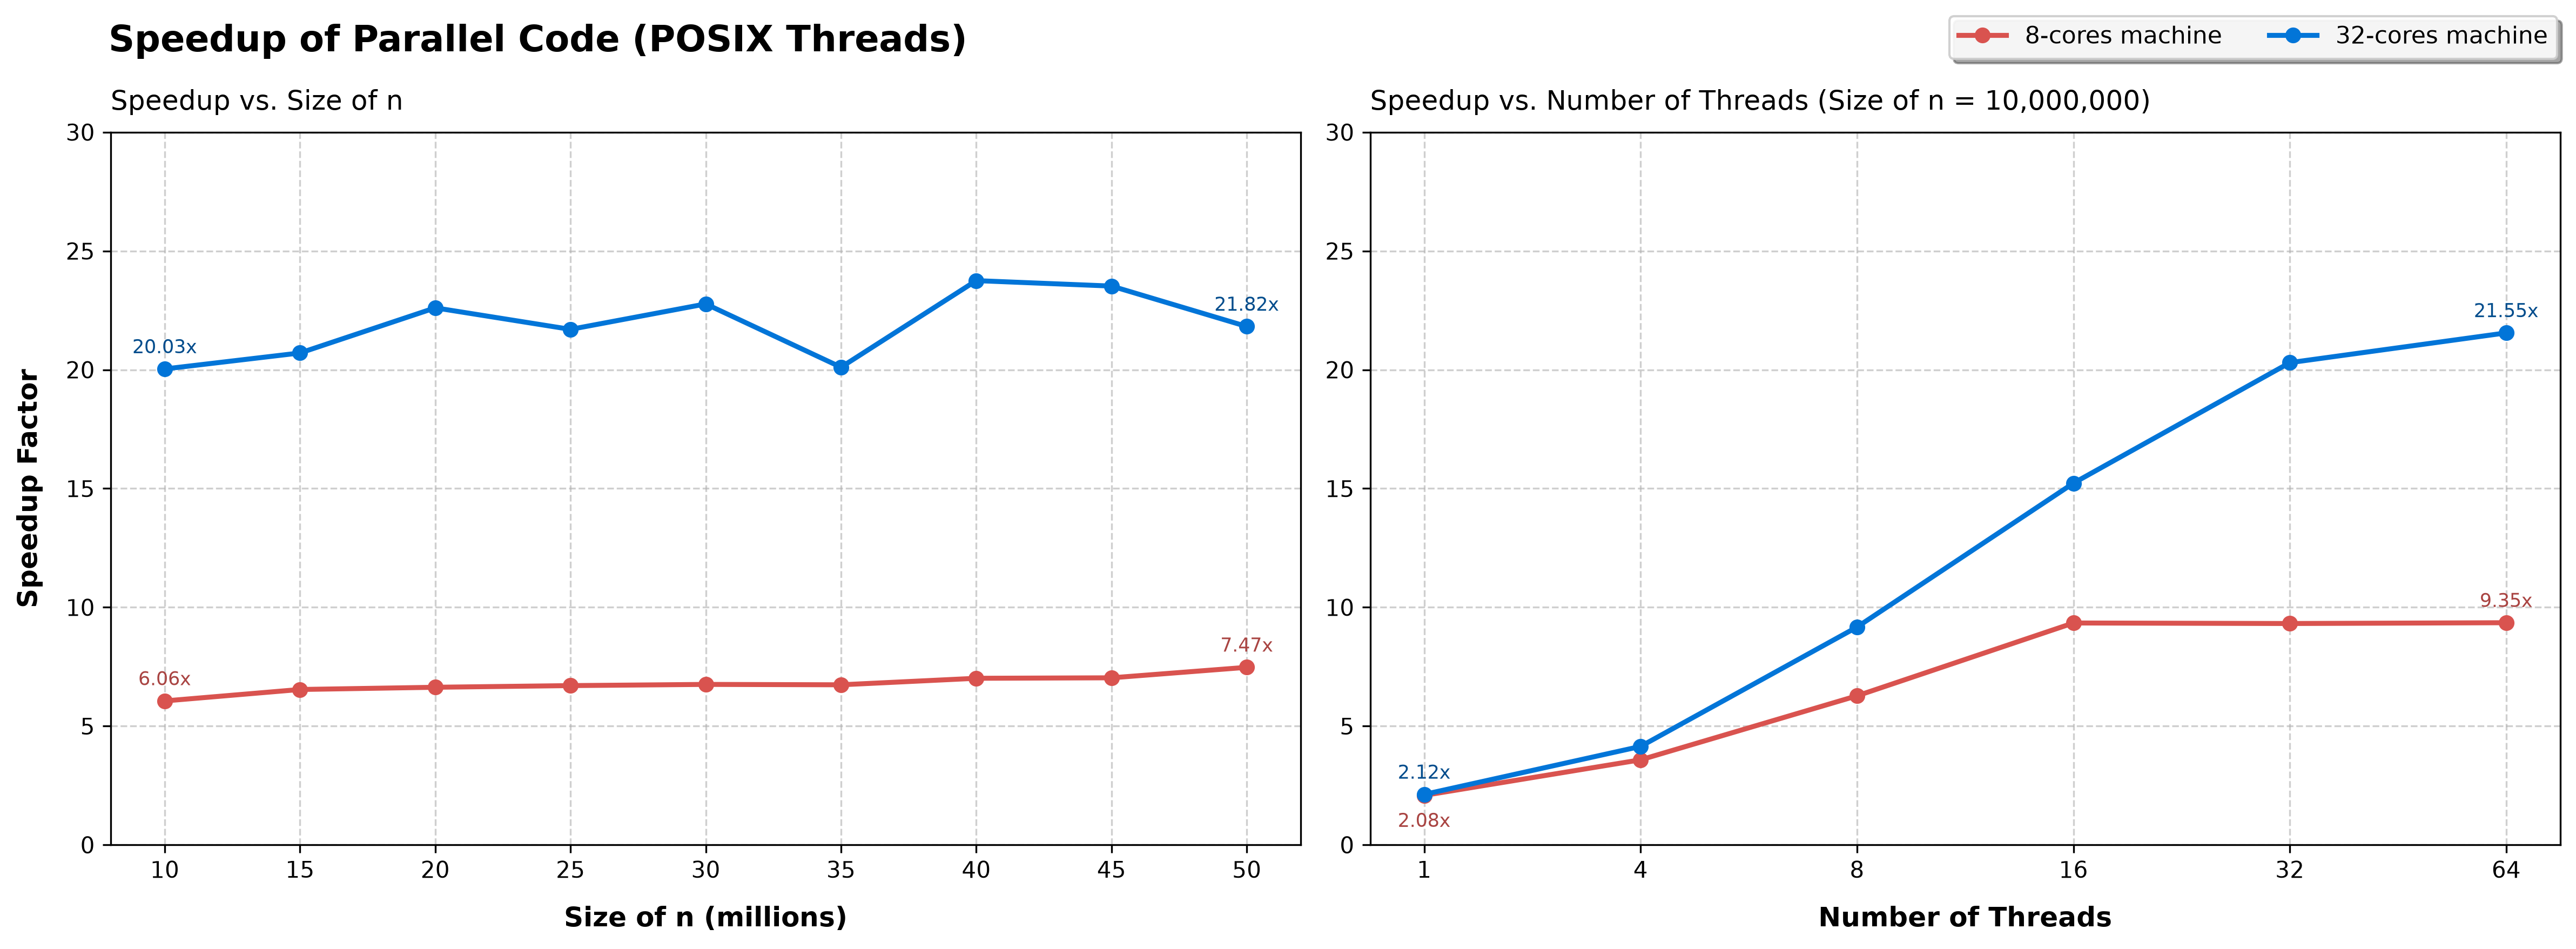

In [48]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=300)

# =============================================================
# Graph 1 (df1): Speedup vs. Size of n (Fixed 8 Threads)
# =============================================================
ax = axes[0]

# 8-core machine speedup
line1, = ax.plot(df1.n, df1.speedup_8cores,
                 marker='o', markersize=6, linewidth=2.2,
                 color='#D9534F', label='8-cores machine')

# 32-core machine speedup
line2, = ax.plot(df1.n, df1.speedup_32cores,
                 marker='o', markersize=6, linewidth=2.2,
                 color='#0275D8', label='32-cores machine')

ax.set_title("Speedup vs. Size of n",
             fontsize=12, loc='left', pad=10)

ax.set_xlabel("Size of n (millions)",
              fontsize=12, fontweight='semibold', labelpad=10)

ax.set_ylabel("Speedup Factor",
              fontsize=12, fontweight='semibold', labelpad=10)

ax.set_xticks(df1.n)
ax.set_xticklabels([f"{x / 1_000_000:g}" for x in df1.n], fontsize=10)

ax.tick_params(axis='y', labelsize=10)
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_ylim(0, 30)

ax.annotate(f"{df1.speedup_8cores.iloc[0]:.2f}x",
            (df1.n.iloc[0], df1.speedup_8cores.iloc[0]),
            textcoords='offset points', xytext=(0, 7), ha='center',
            fontsize=8.5, color='#A94442')

ax.annotate(f"{df1.speedup_8cores.iloc[-1]:.2f}x",
            (df1.n.iloc[-1], df1.speedup_8cores.iloc[-1]),
            textcoords='offset points', xytext=(0, 7), ha='center',
            fontsize=8.5, color='#A94442')

ax.annotate(f"{df1.speedup_32cores.iloc[0]:.2f}x",
            (df1.n.iloc[0], df1.speedup_32cores.iloc[0]),
            textcoords='offset points', xytext=(0, 7), ha='center',
            fontsize=8.5, color='#014C8C')

ax.annotate(f"{df1.speedup_32cores.iloc[-1]:.2f}x",
            (df1.n.iloc[-1], df1.speedup_32cores.iloc[-1]),
            textcoords='offset points', xytext=(0, 7), ha='center',
            fontsize=8.5, color='#014C8C')


# =============================================================
# Graph 2 (df2): Speedup vs. Number of Threads (Fixed n = 10M)
# =============================================================
ax = axes[1]

# 8-core machine speedup
ax.plot(range(len(df2.num_threads)), df2.speedup_8cores,
        marker='o', markersize=6, linewidth=2.2,
        color='#D9534F')

# 32-core machine speedup
ax.plot(range(len(df2.num_threads)), df2.speedup_32cores,
        marker='o', markersize=6, linewidth=2.2,
        color='#0275D8')

ax.set_title("Speedup vs. Number of Threads (Size of n = 10,000,000)",
             fontsize=12, loc='left', pad=10)

ax.set_xlabel("Number of Threads",
              fontsize=12, fontweight='semibold', labelpad=10)

ax.set_xticks(range(len(df2.num_threads)))
ax.set_xticklabels(df2.num_threads, fontsize=10)

ax.tick_params(axis='y', labelsize=10)
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_ylim(0, 30)

ax.annotate(f"{df2.speedup_8cores.iloc[0]:.2f}x",
            (0, df2.speedup_8cores.iloc[0]),
            textcoords='offset points', xytext=(0, -14), ha='center',
            fontsize=8.5, color='#A94442')

ax.annotate(f"{df2.speedup_8cores.iloc[-1]:.2f}x",
            (len(df2.num_threads) - 1, df2.speedup_8cores.iloc[-1]),
            textcoords='offset points', xytext=(0, 7), ha='center',
            fontsize=8.5, color='#A94442')

ax.annotate(f"{df2.speedup_32cores.iloc[0]:.2f}x",
            (0, df2.speedup_32cores.iloc[0]),
            textcoords='offset points', xytext=(0, 7), ha='center',
            fontsize=8.5, color='#014C8C')

ax.annotate(f"{df2.speedup_32cores.iloc[-1]:.2f}x",
            (len(df2.num_threads) - 1, df2.speedup_32cores.iloc[-1]),
            textcoords='offset points', xytext=(0, 7), ha='center',
            fontsize=8.5, color='#014C8C')


# =========================
# Overall title
# =========================
fig.suptitle(
    "Speedup of Parallel Code (POSIX Threads)",
    fontsize=16,
    fontweight='bold',
    x=0.045,
    y=0.96,
    ha='left'
)

# =========================
# Unified Global Legend
# =========================
fig.legend(
    handles=[line1, line2],
    labels=['8-cores machine', '32-cores machine'],
    loc='upper right',
    bbox_to_anchor=(0.994, 0.98),
    ncol=2,
    fontsize=10.5,
    frameon=True,
    framealpha=0.9,
    shadow=True
)

plt.tight_layout(rect=[0, 0, 1, 0.98])

plt.savefig("task2_graph3.png", dpi=300)
plt.show()